Based on https://github.com/XENON1T/LowER/blob/master/LowER/solarnu.py

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [163]:
params = {
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
    'font.family' : 'serif',
    'font.size' : 15,
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    'xtick.major.size' : 8,
    'ytick.major.size' : 8,
    'xtick.major.width' : 1.5,
    'ytick.major.width' : 1.5,
    'axes.linewidth' : 1.5,
    'axes.labelsize' : 17
}

plt.rcParams.update(params)
# plt.rc('text', usetex=True)

In [46]:
class Constants:
    G_f = 1.166e-17# keV^{-2}
    m_e = 511  # keV
    s_w = np.sqrt(0.232)  # PDG
    N_a = 6.02e23
    hbar = 6.58e-19  # keV*s
    c = 3e10  # cm/s
    alpha = 1 / 137
    mu_b = np.sqrt(4 * np.pi * alpha) / (2 * m_e)  # keV^{-1}

class XeShell:
    # (n_electron, energy [keV])
    shells = [(54, 34.561),
              (52, 5.453),
              (50, 5.107),
              (47 ,4.786),
              (44, 1.148),
              (42, 1.002),
              (39, 0.941),
              (36, 0.689),
              (31, 0.676),
              (26, 0.213),
              (24, 0.147),
              (21, 0.145),
              (18, 0.070),
              (13, 0.068),
              (8, 0.023),
              (6, 0.013),
              (3, 0.012)
              ]
    k_shell = shells[0][1]
    outer_shell = shells[-1][1]

    def __init__(self):
        pass

    def num_accessible(self, E):
        if hasattr(E, '__len__'):
            return np.array([self.num_accessible(e) for e in E])
        if E >= self.k_shell:
            return 54
        elif E < self.outer_shell:
            return 0
        else:
            next_shell = self.k_shell
            for n, e in self.shells:
                if e < E <= next_shell:
                    return n
            return 3



C = Constants()
Xe = XeShell()

# Standard model CC-interaction spectrum

In [94]:
def max_recoil_energy(Enu):
    # in keV
    return 2*Enu**2 / (C.m_e + 2*Enu)

def min_Enu(Er):
    # minimum neutrino energy in keV
    return 0.5 * (Er + np.sqrt(Er**2 + 2*Er*C.m_e))

def SM_diff_xsec(Er, Enu, nu='e', stepping=False):
    """returns Standard Model differential cross section in units of cm^2/keV"""
    # break into a few parts for readability

    a = C.G_f ** 2 * C.m_e / (2 * np.pi * Enu ** 2)
    b = 4 * C.s_w ** 4 * (2 * Enu ** 2 + Er ** 2 - Er * (2 * Enu + C.m_e))
    c = 2 * C.s_w ** 2 * (Er * C.m_e - 2 * Enu ** 2)
    si_corr = (C.hbar * C.c) ** 2

    stepping_corr = Xe.num_accessible(Er) / 54 if stepping else 1.0

    if nu == 'e':
        ret = a * (b - c + Enu ** 2) * si_corr * stepping_corr
    elif nu in ['mu', 'tau']:
        ret = a * (b + c + Enu ** 2) * si_corr * stepping_corr
    else:
        raise NotImplementedError("nu type needs to be e, mu, tau!")

    return ret * (Er <= max_recoil_energy(Enu)) * (Enu > min_Enu(Er))
        
class SolarNu:

    def dRdE_SM(self, Er, E_nu, nu='e', stepping=False, p=None):
        """SM differential rate, in units events/ton/keV"""
        # so that it can handle arrays
        if hasattr(Er, "__len__"):
            return np.array([self.dRdE_SM(E, E_nu, nu, stepping=stepping, p=p) for E in Er])

        # needs to be cm^2/keV

        xsec = ((1/3 * SM_diff_xsec(Er, E_nu, nu='e', stepping=stepping) +
                     (1 - 1/3) * SM_diff_xsec(Er, E_nu, nu='mu', stepping=stepping))
                    )
   

        # f(_ev)=F*delta(_ev), so no-integration         

        return xsec * (C.N_a/131.3) * 54 * 1e6

In [95]:
nu = SolarNu()

In [96]:
stepping = True

In [97]:
Es = np.linspace(0, 210, 211)

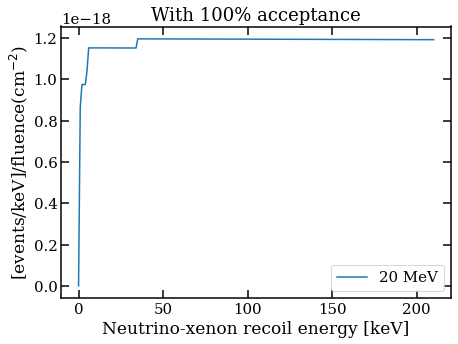

In [167]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

rates = nu.dRdE_SM(Es, 20000.0, stepping=stepping)
plt.plot(Es, rates, label="20 MeV")
ax.set_title("With 100% acceptance")
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()

plt.show()

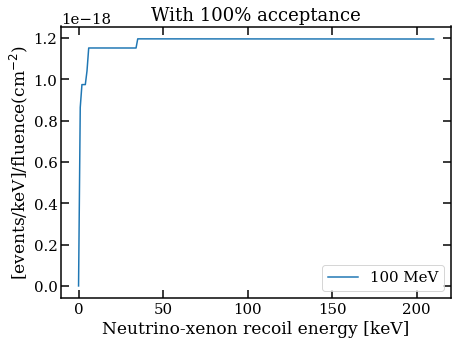

In [168]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

rates = nu.dRdE_SM(Es, 100000.0, stepping=stepping)
plt.plot(Es, rates, label="100 MeV")
ax.set_title("With 100% acceptance")
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()

plt.show()

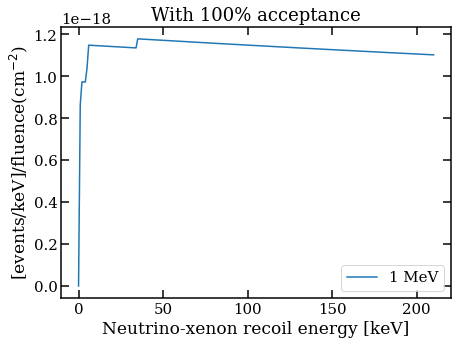

In [169]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

rates = nu.dRdE_SM(Es, 1000.0, stepping=stepping)
plt.plot(Es, rates, label="1 MeV")
ax.set_title("With 100% acceptance")
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()

plt.show()

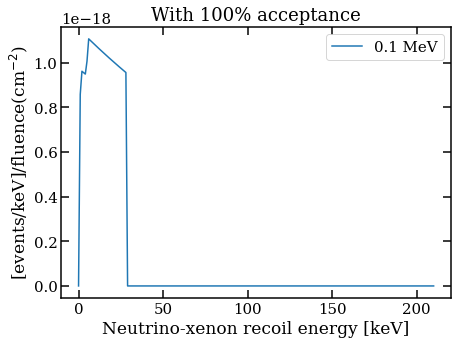

In [170]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

rates = nu.dRdE_SM(Es, 100.0, stepping=stepping)
plt.plot(Es, rates, label="0.1 MeV")
ax.set_title("With 100% acceptance")
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()

plt.show()

# Acceptance

ER_efficiency.csv is created using https://github.com/XENON1T/LowER/blob/master/analysis/paper/signal_models.ipynb

where 'Energy' = xs = np.linspace(0, 210, 1000) and 'Efficiency' = eff = efficiency(xs, errors=True, sciencerun='sr1')

In [107]:
acc_data = pd.read_csv('/depot/darkmatter/data/jupyterhub/Riya/ER_efficiency.csv')
accept = acc_data['Efficiency']
energy_ER = acc_data['Energy']
accept_ER = interp1d(energy_ER, accept, bounds_error=False, fill_value=0, kind='linear')

No handles with labels found to put in legend.


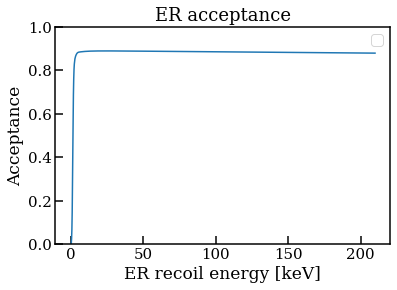

In [176]:
plt.plot(energy_ER, accept_ER(energy_ER))
plt.xlabel('ER recoil energy [keV]')
plt.ylabel('Acceptance')
plt.title("ER acceptance")
plt.ylim(0,1)
plt.legend()
plt.show()

# Events in 1 tonne detector at fixed Energy

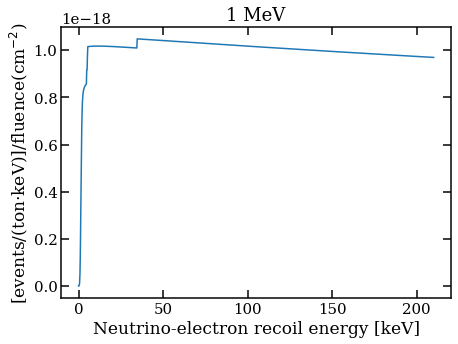

In [181]:
rates = [nu.dRdE_SM(x, 1000.0, stepping=stepping) * accept_ER(x) for x in energy_ER]
fig, ax = plt.subplots(1, 1, figsize=(7,5))

plt.plot(energy_ER, rates)
ax.set_title(r"1 MeV")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

# Events in our detector at fixed Energy

In [182]:
fm_ER = 1.042


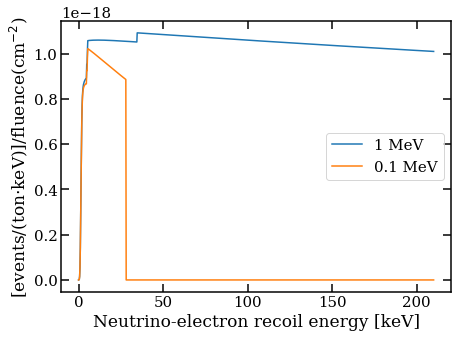

In [186]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
rates = [nu.dRdE_SM(x, 1000.0, stepping=stepping) * accept_ER(x) * fm_ER for x in energy_ER] 
plt.plot(energy_ER, rates, label = "1 MeV")

rates = [nu.dRdE_SM(x, 100.0, stepping=stepping) * accept_ER(x) * fm_ER for x in energy_ER] 
plt.plot(energy_ER, rates, label = "0.1 MeV")

plt.legend()
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

# Events in detector for neutrino energies

In [189]:
np.logspace(-1, 2, 101)

array([  0.1       ,   0.10715193,   0.11481536,   0.12302688,
         0.13182567,   0.14125375,   0.15135612,   0.16218101,
         0.17378008,   0.18620871,   0.19952623,   0.21379621,
         0.22908677,   0.24547089,   0.2630268 ,   0.28183829,
         0.30199517,   0.32359366,   0.34673685,   0.37153523,
         0.39810717,   0.42657952,   0.45708819,   0.48977882,
         0.52480746,   0.56234133,   0.60255959,   0.64565423,
         0.69183097,   0.74131024,   0.79432823,   0.85113804,
         0.91201084,   0.97723722,   1.04712855,   1.12201845,
         1.20226443,   1.28824955,   1.38038426,   1.47910839,
         1.58489319,   1.69824365,   1.81970086,   1.9498446 ,
         2.08929613,   2.23872114,   2.39883292,   2.57039578,
         2.7542287 ,   2.95120923,   3.16227766,   3.38844156,
         3.63078055,   3.89045145,   4.16869383,   4.46683592,
         4.78630092,   5.12861384,   5.49540874,   5.88843655,
         6.30957344,   6.76082975,   7.2443596 ,   7.76

In [190]:
Neutrino_Energy = np.logspace(-1, 2, 101)*1000
def calc_rate_Ev(energy, accept, fm):
    total_rate_Ev = []
    for Ev in Neutrino_Energy:
        total_rate = 0
        for i in range(0,np.shape(energy)[0]-1):
            er = (energy[i]+energy[i+1])/2
            delta_energy = energy[i+1] - energy[i]
            rate = nu.dRdE_SM(er, Ev, stepping=stepping) * accept(er)
            total_rate = total_rate + rate * delta_energy * fm 
        total_rate_Ev.append(total_rate)
    return(np.array(total_rate_Ev))

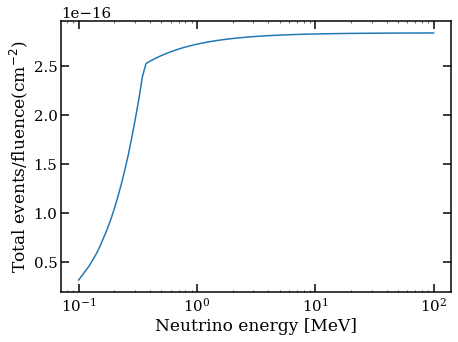

In [193]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

plt.plot(Neutrino_Energy/1000, calc_rate_Ev(Es, accept_ER, fm_3fold))
plt.xscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.show()

# Set constraints

In [194]:
upper_lim_fluence = 2.3/calc_rate_Ev(Es, accept_ER, fm_3fold)

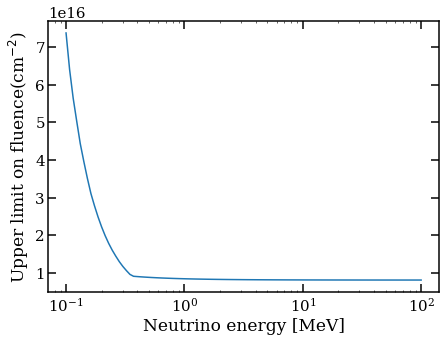

In [195]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

plt.plot(Neutrino_Energy/1000, upper_lim_fluence)
plt.xscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.show()

Checking if S2-only is useful

In [149]:
acc_data = pd.read_csv('/depot/darkmatter/data/jupyterhub/Riya/s2only_efficiency.csv')
accept = acc_data['Efficiency']*0.7 #because 30% of data is used for training
energy_S2only = acc_data['Energy'] 
accept_S2only = interp1d(energy_S2only, accept, bounds_error=False, fill_value=0, kind='linear')

<ipython-input-94-3c49d0dba54d>:13: RuntimeWarning: divide by zero encountered in double_scalars
  a = C.G_f ** 2 * C.m_e / (2 * np.pi * Enu ** 2)
<ipython-input-94-3c49d0dba54d>:27: RuntimeWarning: invalid value encountered in multiply
  return ret * (Er <= max_recoil_energy(Enu)) * (Enu > min_Enu(Er))


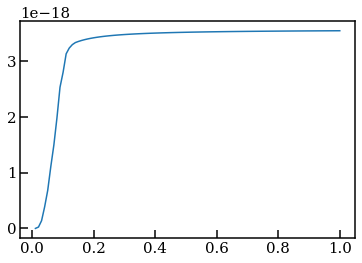

In [171]:
plt.plot(Neutrino_Energy/1000, calc_rate_Ev(energy_S2only, accept_S2only, fm_3fold*2), label="S2only")
#plt.plot(Neutrino_Energy/1000, calc_rate_Ev(Es, accept_ER, fm_3fold), label="ER")
plt.show()

<ipython-input-94-3c49d0dba54d>:13: RuntimeWarning: divide by zero encountered in double_scalars
  a = C.G_f ** 2 * C.m_e / (2 * np.pi * Enu ** 2)
<ipython-input-94-3c49d0dba54d>:27: RuntimeWarning: invalid value encountered in multiply
  return ret * (Er <= max_recoil_energy(Enu)) * (Enu > min_Enu(Er))
<ipython-input-94-3c49d0dba54d>:13: RuntimeWarning: divide by zero encountered in double_scalars
  a = C.G_f ** 2 * C.m_e / (2 * np.pi * Enu ** 2)
<ipython-input-94-3c49d0dba54d>:27: RuntimeWarning: invalid value encountered in multiply
  return ret * (Er <= max_recoil_energy(Enu)) * (Enu > min_Enu(Er))


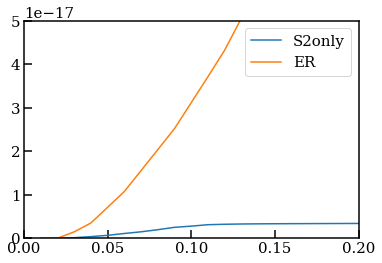

In [172]:
plt.plot(Neutrino_Energy/1000, calc_rate_Ev(energy_S2only, accept_S2only, fm_3fold*2), label="S2only")
plt.plot(Neutrino_Energy/1000, calc_rate_Ev(Es, accept_ER, fm_3fold), label="ER")
plt.xlim(0, 0.2)
plt.ylim(0, 0.5*1e-16)
plt.legend()
plt.show()